# Metabarcoding Workbench
**A FAIR, one-click eDNA metabarcoding pipeline**

`Raw FASTQ -> ASV table (DADA2) -> Taxonomy (dnabarcoder) -> Plots (R/ggplot)` **More tool options are going to be added**

### How to use this notebook
1. Edit the **Settings** cell below
2. Press *Run > Run All Cells 
3. Every step prints its progress, and plots are outputted at the end

Each step calls the same scripts that exist in `scripts/`, so the noteboook and the command-line workflow always give the identical results. Steps whose outputs already exist are skepped.

## Settings

**You should adjust this to whatever fits *your* data**

In [17]:
import os, sys

# ---------------- Command-line arguments---------------------------------
BIOPROJECT = "PRJNA934949"   # 01_download.py  <bioproject>
LIMIT      = 5               # 01_download.py  --limit
REGION     = "its2"          # 03_taxonomy.py / 04a_visualization.R  --region   (its1, its2, its)
NCPUS      = 4               # 03_taxonomy.py  --ncpus
RANK       = "genus"         # 04a_visualization.R  --rank   (phylum, class, order, family, genus, species)

# Optional, only if R / BLAST are not on your PATH (as in the README):
R_BIN_DIR     = "C:/Program Files/R/R-4.4.1/bin"        
BLAST_BIN_DIR = "C:/Users/theos/Downloads/ncbi-blast-2.17.0+-x64-win64/ncbi-blast-2.17.0+/bin"     
# --------------------------------------------------------------------------

# run from the project root
if not os.path.isdir("scripts") and os.path.isdir("../scripts"):
    os.chdir("..")
for d in (R_BIN_DIR, BLAST_BIN_DIR):
    if d:
        os.environ["PATH"] += os.pathsep + d
print("Working directory:", os.getcwd())

Working directory: d:\metabarcoding-workbench


In [18]:
import time
try:
    import ipywidgets as w
    from IPython.display import display
    STEPS = 5
    bar = w.IntProgress(value=0, min=0, max=STEPS, description="Pipeline", bar_style="info",
                        layout=w.Layout(width="55%"))
    label = w.Label("Not started")
    display(w.HBox([bar, label]))
except ImportError:
    bar = label = None

_state = {"t": time.time(), "failed": False}

def step_start(name):
    _state["t"] = time.time()
    if bar:
        label.value = "Running: " + name
    else:
        print(">>> Running:", name)

def step_done(name, exit_code):
    mins = (time.time() - _state["t"]) / 60
    ok = (exit_code == 0)
    _state["failed"] = _state["failed"] or not ok
    if bar:
        if ok:
            bar.value += 1
        bar.bar_style = "danger" if _state["failed"] else ("success" if bar.value == bar.max else "info")
        label.value = (f"{name}: finished in {mins:.1f} min" if ok
                       else f"{name}: FAILED (exit code {exit_code}) - see output below")
        if ok and bar.value == bar.max and not _state["failed"]:
            label.value = "All steps finished"
    else:
        print(f"<<< {name}: " + ("finished" if ok else f"FAILED (exit code {exit_code})"), f"({mins:.1f} min)")

### 1. Check the Setup

In [19]:
!python scripts/00_check_setup.py
!Rscript --version
!blastn -version
!Rscript -e "library(ggplot2); library(vegan); library(dada2); library(ShortRead); cat('All required R packages loaded successfully.\n')"

Python: 3.14.7
Bio: OK
sklearn: OK
matplotlib: OK
pandas: OK
Rscript: C:/Program Files/R/R-4.4.1/bin\Rscript.EXE

Python setup looks good.
Rscript (R) version 4.4.1 (2024-06-14)
blastn: 2.17.0+
 Package: blast 2.17.0, build Jul  1 2025 08:57:20
All required R packages loaded successfully.


Warning message:
package 'ggplot2' was built under R version 4.4.3 
Loading required package: permute
Warning message:
package 'permute' was built under R version 4.4.3 
Loading required package: Rcpp
Loading required package: BiocGenerics

Attaching package: 'BiocGenerics'

The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs

The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min

Loading required package: BiocParallel
Loading required package: Biostrings
Loading required package: S4Vectors
Loading required package: stats4

Attaching package: 'S4Vectors'

Th

### 2. Download raw FASTQ data

In [20]:
!python scripts/01_download.py {BIOPROJECT} --limit {LIMIT}

Querying ENA: PRJNA934949 | PAIRED
Runs returned: 271
Paired-end runs selected: 271
Limited run selection to first 5 samples.
Metadata: D:\metabarcoding-workbench\results\PRJNA934949_download_manifest.tsv

[1/5] SRR23641999

    SRR23641999_1.fastq.gz:  23.22%
    SRR23641999_1.fastq.gz:  46.44%
    SRR23641999_1.fastq.gz:  69.65%
    SRR23641999_1.fastq.gz:  92.87%
    SRR23641999_1.fastq.gz: 100.00%

    SRR23641999_2.fastq.gz:  22.00%
    SRR23641999_2.fastq.gz:  44.01%
    SRR23641999_2.fastq.gz:  66.01%
    SRR23641999_2.fastq.gz:  88.01%
    SRR23641999_2.fastq.gz: 100.00%
  Pair ready.

[2/5] SRR23642002

    SRR23642002_1.fastq.gz:  25.25%
    SRR23642002_1.fastq.gz:  50.50%
    SRR23642002_1.fastq.gz:  75.75%
    SRR23642002_1.fastq.gz: 100.00%

    SRR23642002_2.fastq.gz:  24.33%
    SRR23642002_2.fastq.gz:  48.66%
    SRR23642002_2.fastq.gz:  73.00%
    SRR23642002_2.fastq.gz:  97.33%
    SRR23642002_2.fastq.gz: 100.00%
  Pair ready.

[3/5] SRR23642014

    SRR23642014_1.fas

### 3. Filtering and denoising (DADA2)
*This step may take a while to run*

In [21]:
step_start('DADA2')
!Rscript scripts/02_dada2.R
step_done('DADA2', _exit_code)

>>> Running: DADA2

Found 5 candidate paired samples.

Checking FASTQ integrity...
KEEP  SRR23641999
KEEP  SRR23642002
KEEP  SRR23642014
KEEP  SRR23642023
KEEP  SRR23642026

Filtering 5 complete pairs...
                       reads.in reads.out
SRR23641999_1.fastq.gz   125427    104203
SRR23642002_1.fastq.gz   102397     81191
SRR23642014_1.fastq.gz   109654     93742
SRR23642023_1.fastq.gz   129772    122430
SRR23642026_1.fastq.gz   135603    109605

Learning forward error rates without quality scores...
120469800 total bases in 401566 reads from 4 samples will be used for learning the error rates.

Learning reverse error rates without quality scores...
120469800 total bases in 401566 reads from 4 samples will be used for learning the error rates.

Denoising forward reads...
Sample 1 - 104203 reads in 52741 unique sequences.
Sample 2 - 81191 reads in 46883 unique sequences.
Sample 3 - 93742 reads in 38839 unique sequences.
Sample 4 - 122430 reads in 32908 unique sequences.
Sample 5 -

44636 paired-reads (in 218 unique pairings) successfully merged out of 91626 (in 2786 pairings) input.
38798 paired-reads (in 249 unique pairings) successfully merged out of 71193 (in 2254 pairings) input.
36510 paired-reads (in 122 unique pairings) successfully merged out of 85466 (in 2868 pairings) input.
97487 paired-reads (in 213 unique pairings) successfully merged out of 116839 (in 1275 pairings) input.
51361 paired-reads (in 217 unique pairings) successfully merged out of 97890 (in 2626 pairings) input.
Identified 255 bimeras out of 829 input sequences.


### 4. Taxonomic assignment (dnabarcoder)

In [22]:
step_start('Taxonomy')
!python scripts/03_taxonomy.py --region {REGION} --ncpus {NCPUS}
step_done('Taxonomy', _exit_code)

>>> Running: Taxonomy
03 — DNA BARCODER TAXONOMY (ITS2)
Project:   D:\metabarcoding-workbench
ASVs:      D:\metabarcoding-workbench\dnabarcoder_input\asvs.fasta
Reference: unite2025ITS2

Classification code:
  D:\metabarcoding-workbench\dnabarcoder\classification\classify.py

unite2025ITS2: BLAST SEARCH
Using existing BLAST database: D:\metabarcoding-workbench\references\unite2025ITS2.blastdb

$ blastn -query D:\metabarcoding-workbench\results\dnabarcoder\asvs.unite2025ITS2_BLAST.indexed.fasta -db D:\metabarcoding-workbench\references\unite2025ITS2.blastdb -task blastn-short -outfmt 6 -out D:\metabarcoding-workbench\results\dnabarcoder\asvs.unite2025ITS2_BLAST.blastoutput -num_threads 4
Best matches written: 574/574

unite2025ITS2: DNABARCODER CLASSIFICATION

$ d:\metabarcoding-workbench\.venv\Scripts\python.exe D:\metabarcoding-workbench\dnabarcoder\classification\classify.py -i asvs.unite2025ITS2_BLAST.bestmatch -c D:\metabarcoding-workbench\references\unite2025ITS2.classification -c

'ktImportText' is not recognized as an internal or external command,
operable program or batch file.


### 5. Visualization

In [23]:
!Rscript scripts/04_visualization.R --region {REGION} --rank {RANK}

VISUALIZATION SETUP
Project root:  D:/metabarcoding-workbench 
Region:        ITS2 
Taxon Rank:    genus 

ASV table:
  Samples:  5 
  ASVs:     574 

Taxonomy file:
   D:/metabarcoding-workbench/results/dnabarcoder/asvs.unite2025its2_BLAST.classified 

ASVs assigned to genus: 502 / 574

VISUALIZATION COMPLETE


Warning message:
package 'ggplot2' was built under R version 4.4.3 
Loading required package: permute
Warning message:
package 'permute' was built under R version 4.4.3 


### Results

### Genus Total Abundance Its2

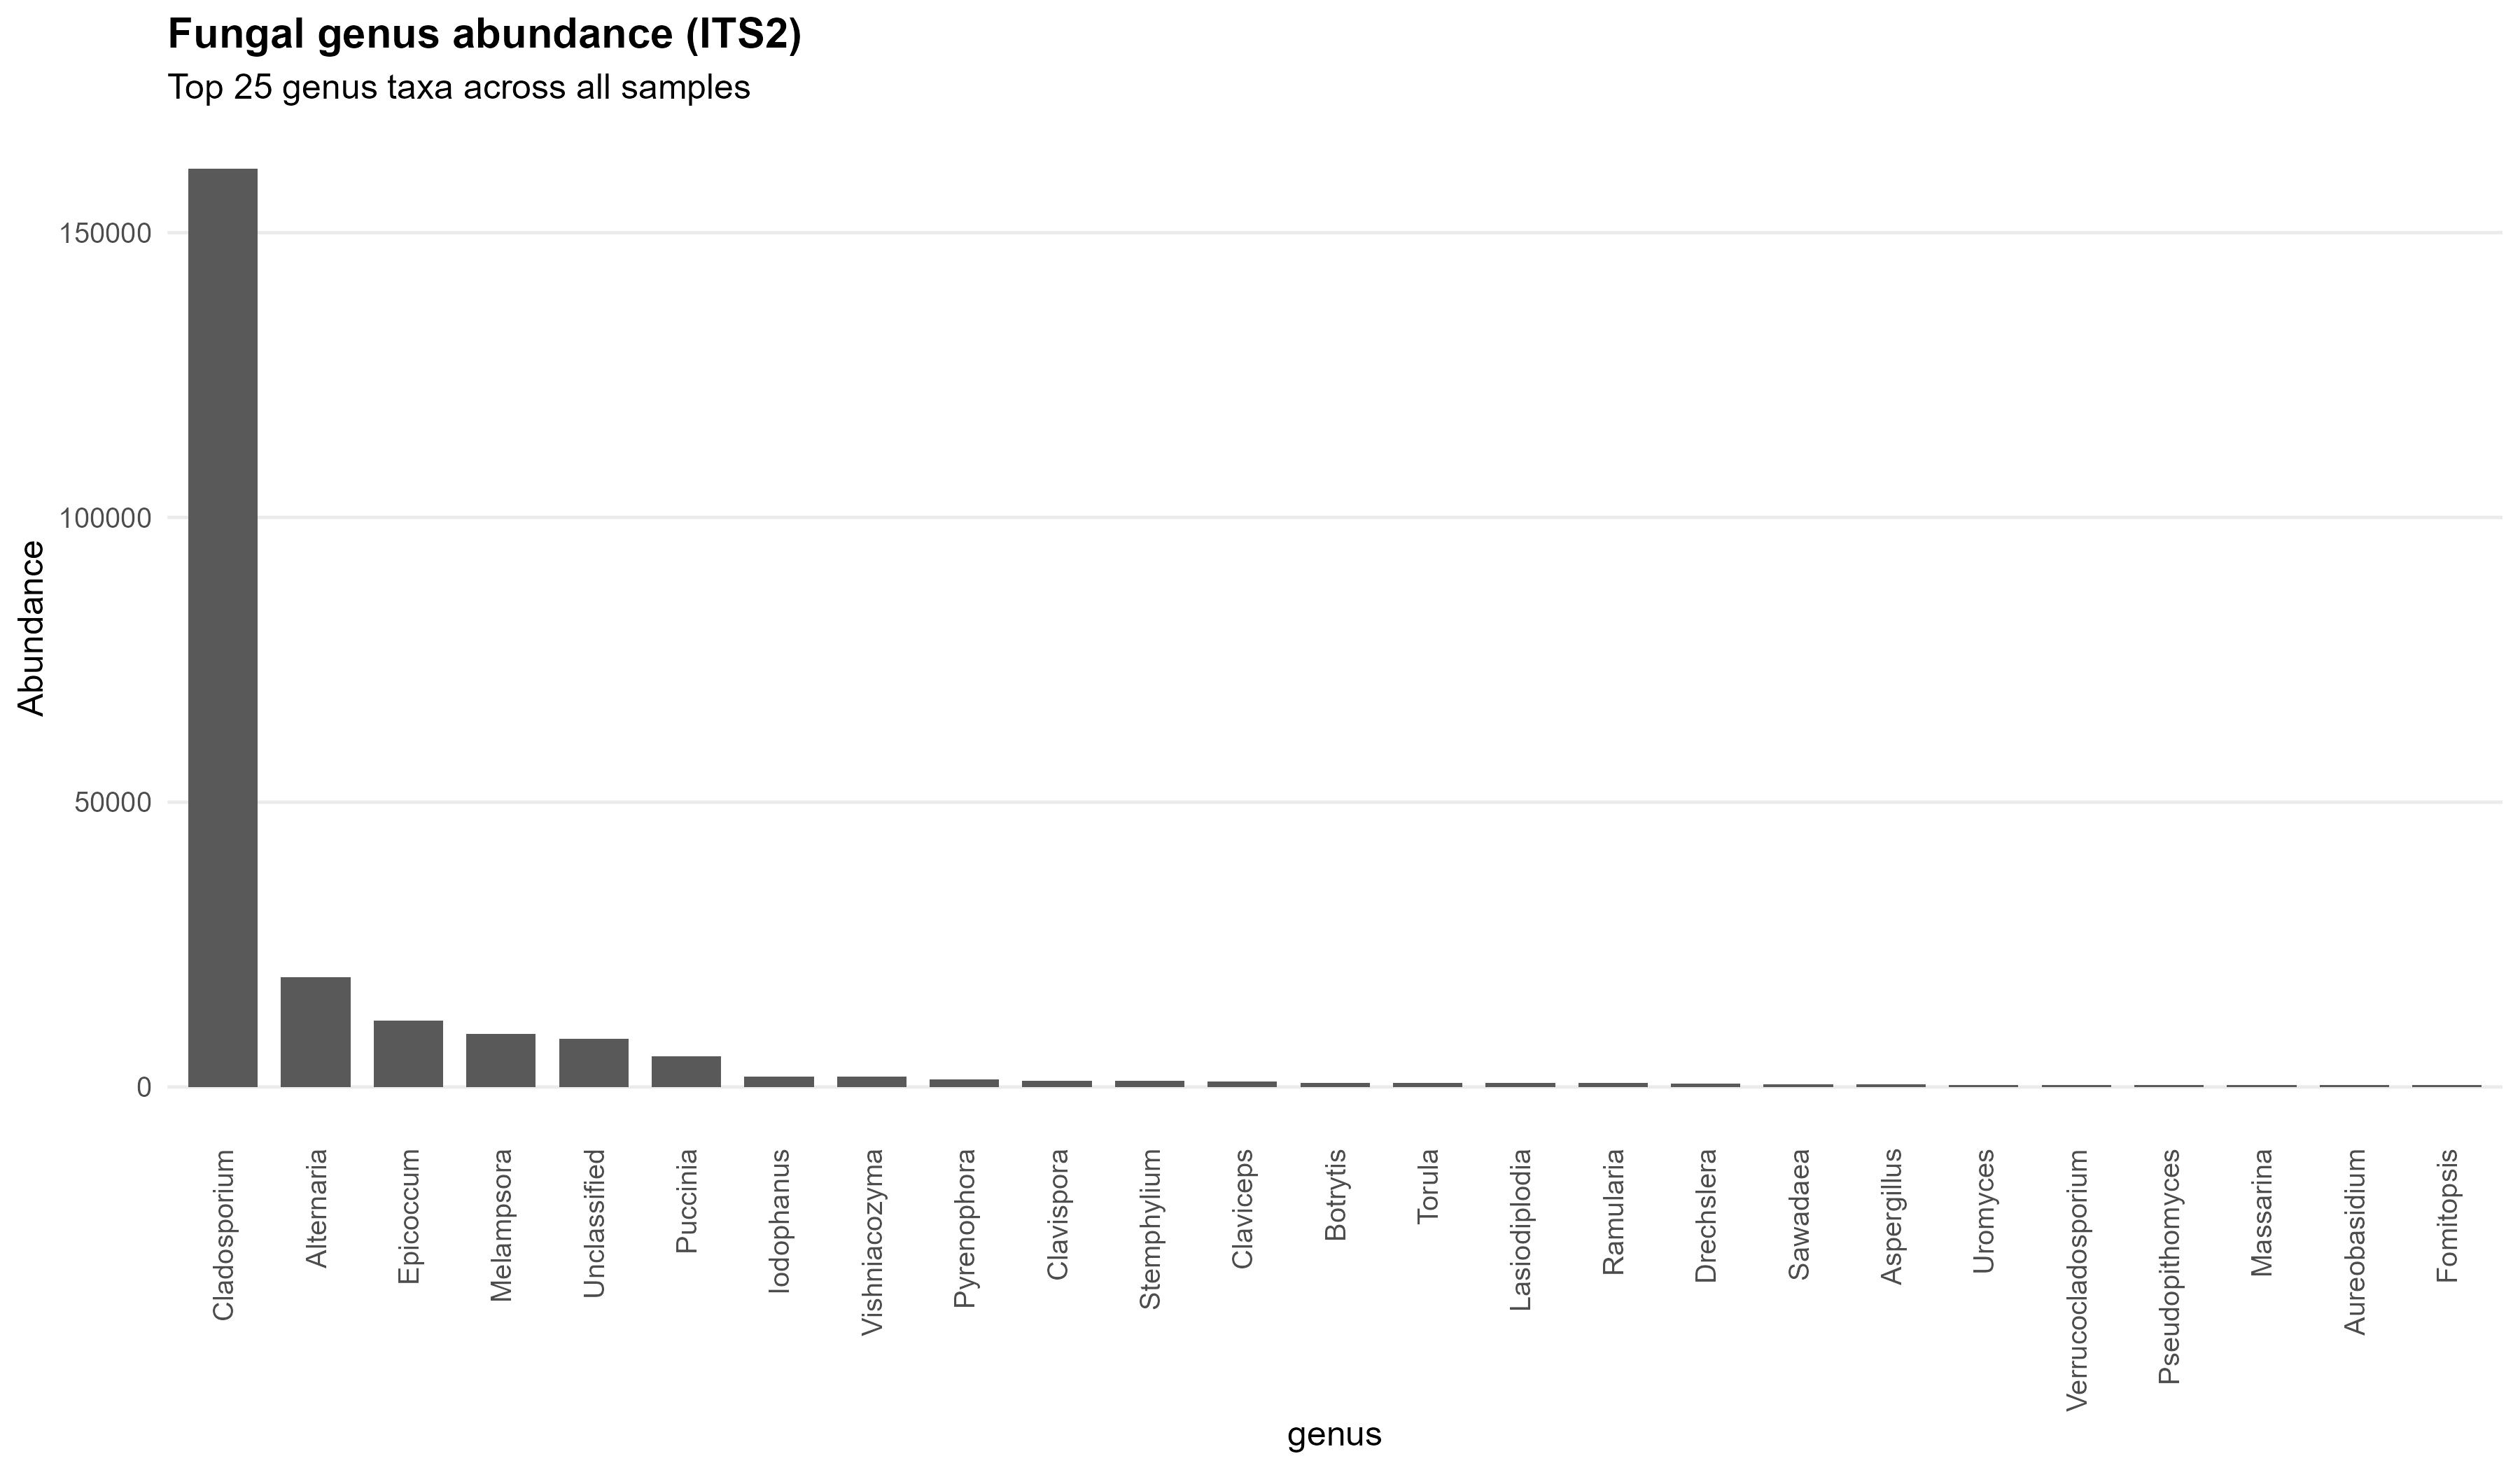

### Genus Relative Abundance Its2

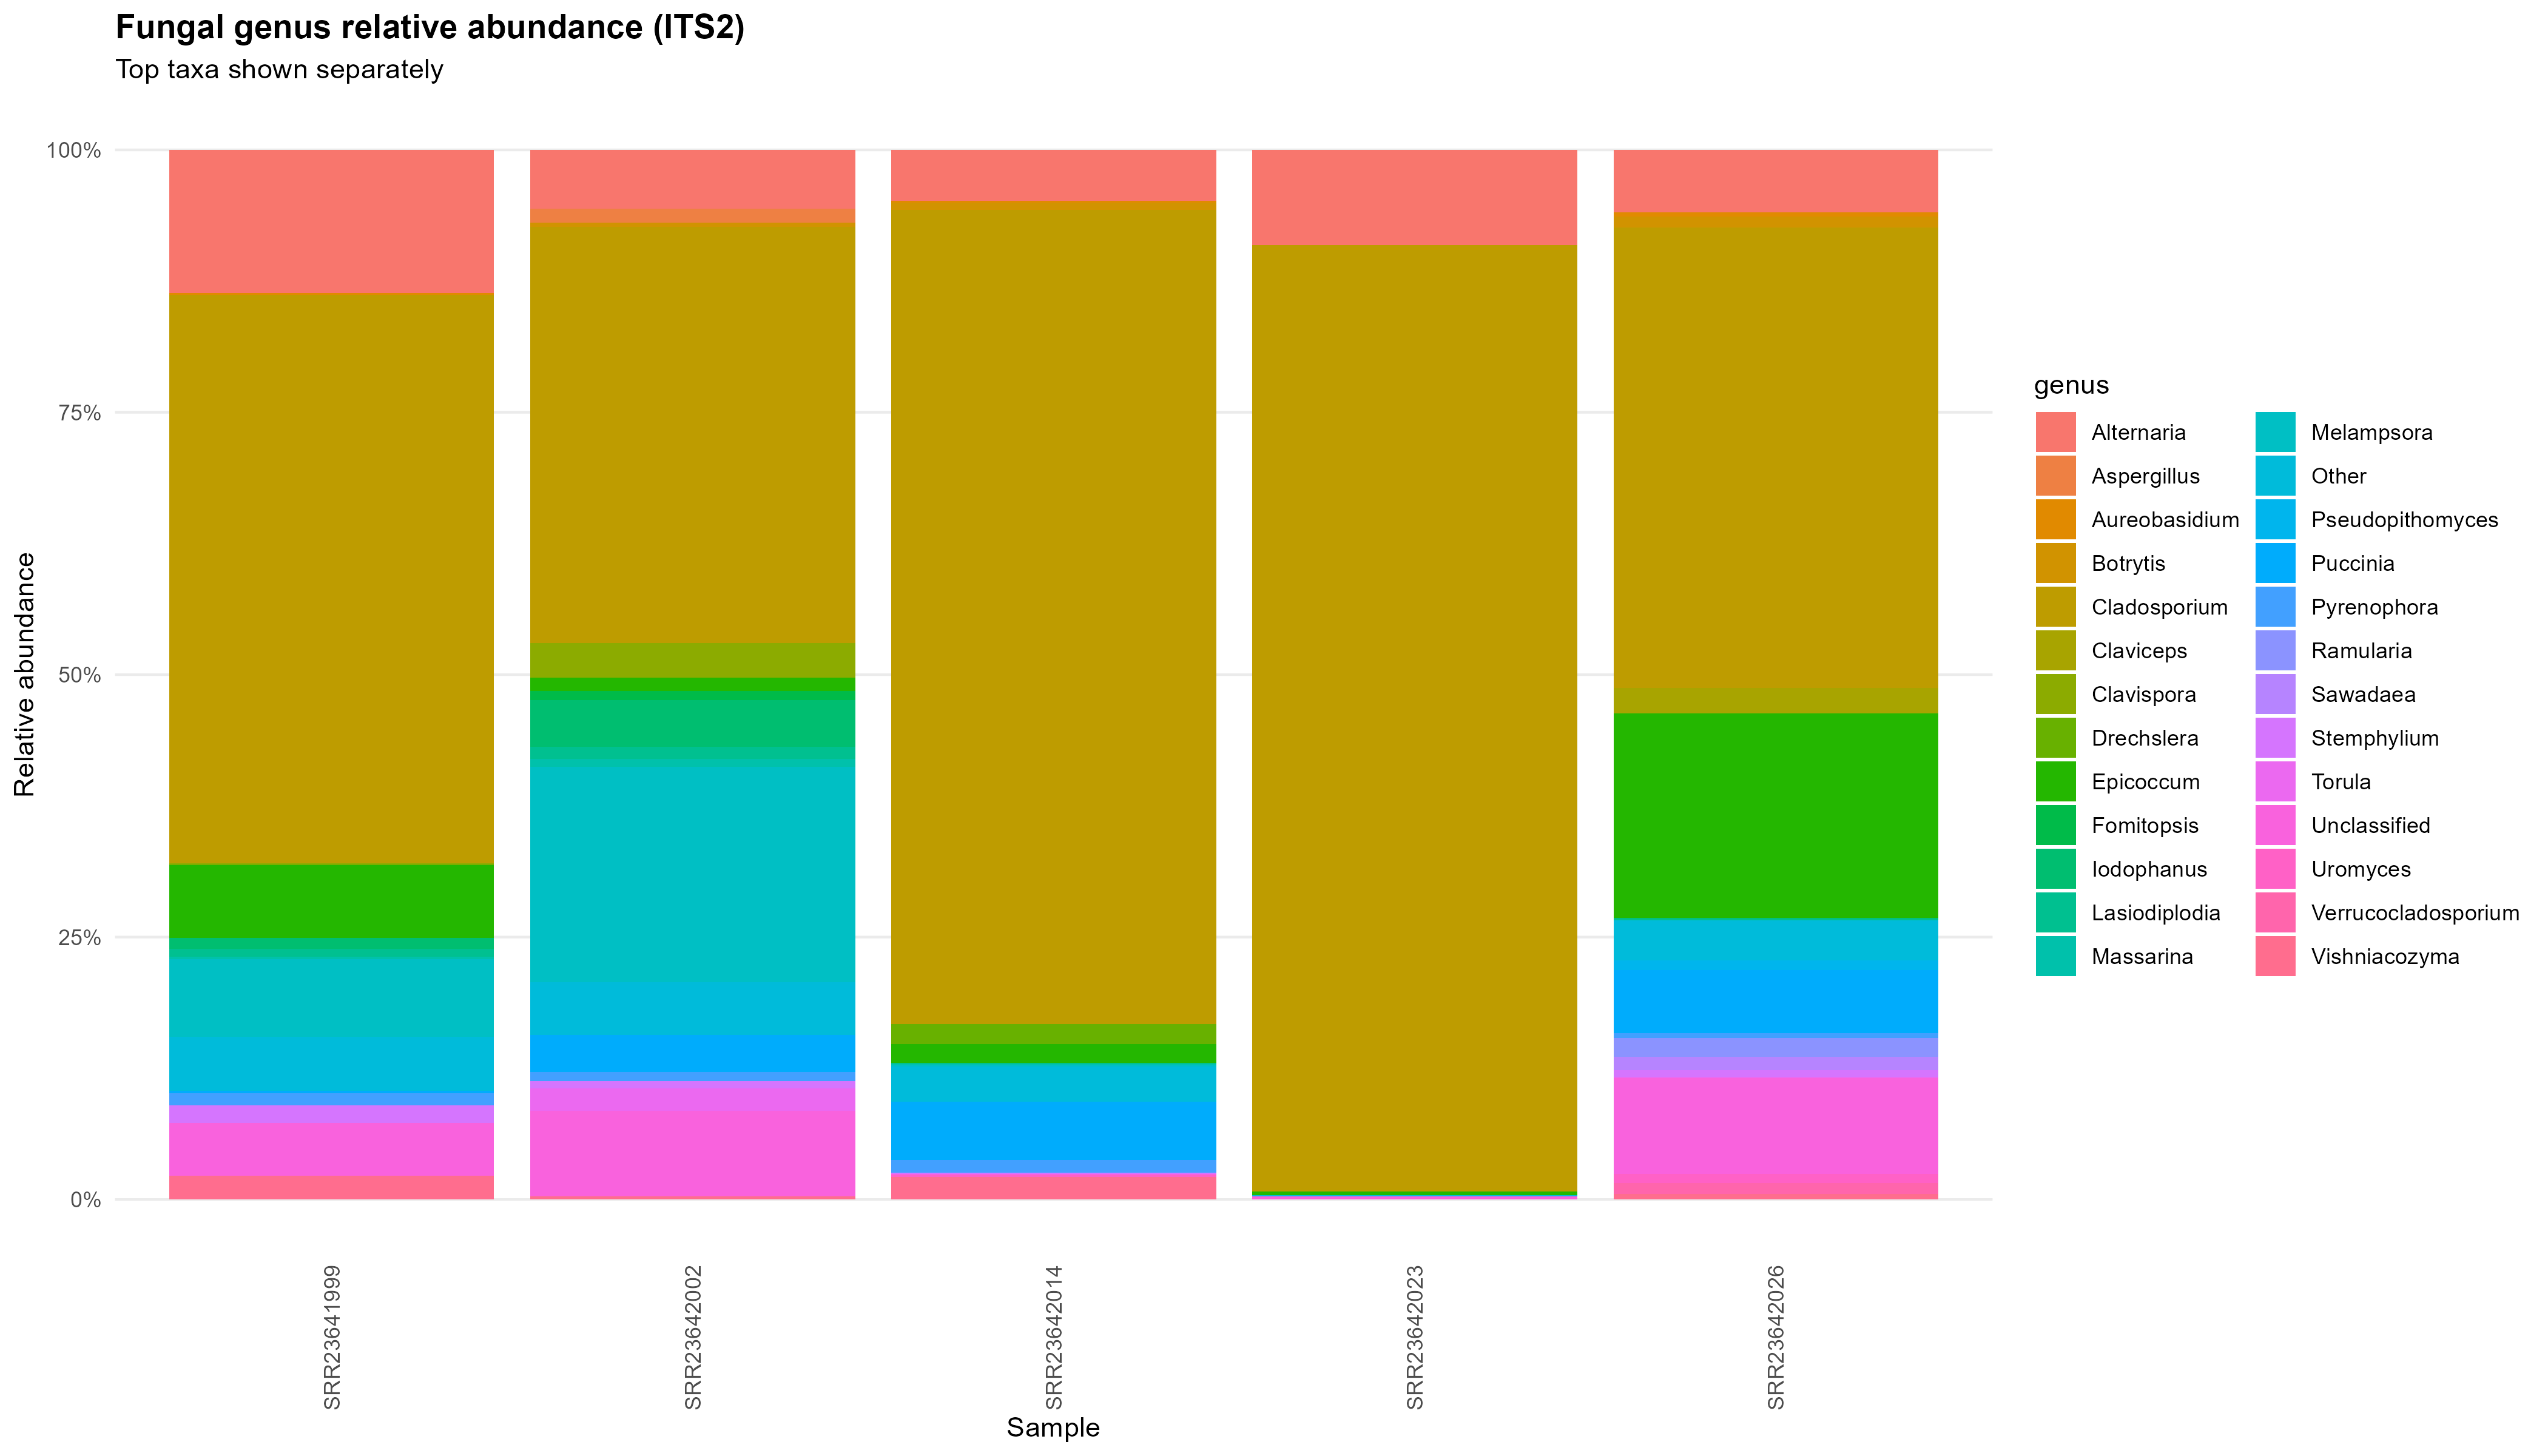

### Bray Curtis Pcoa Genus Its2

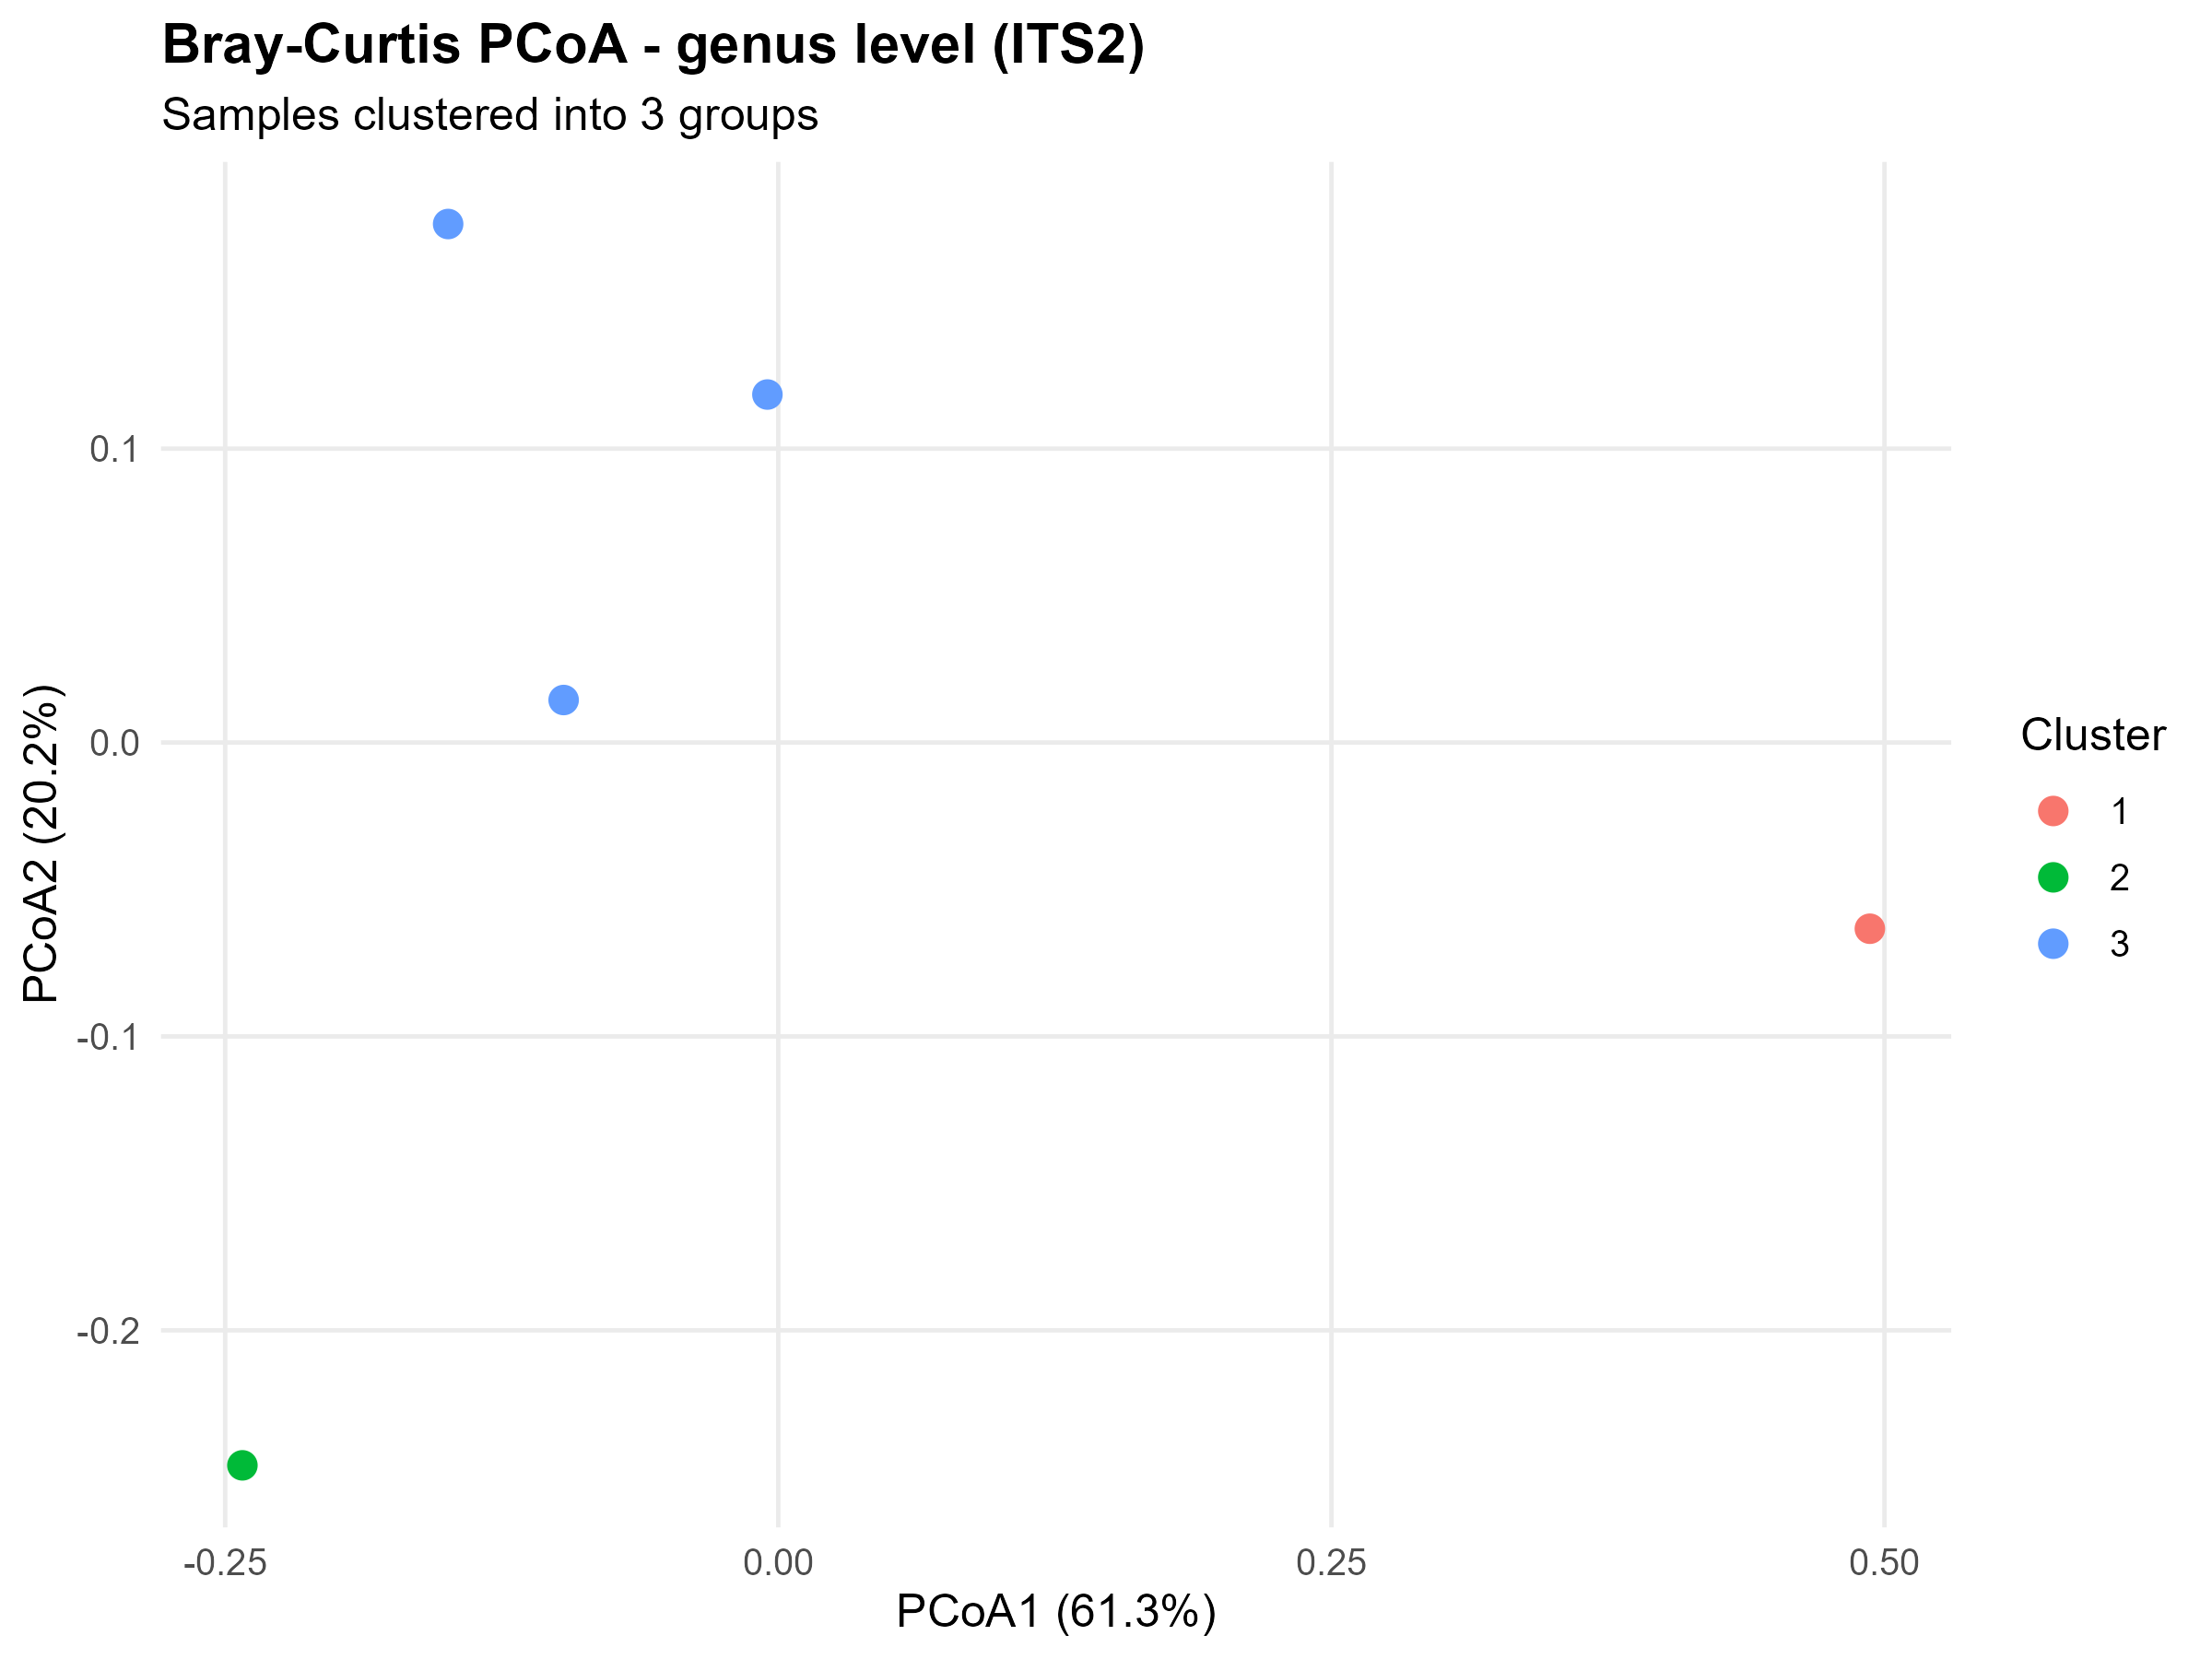

In [24]:
from pathlib import Path
from IPython.display import Image, Markdown, display

plots = [f"{RANK}_total_abundance_{REGION}.png",
         f"{RANK}_relative_abundance_{REGION}.png",
         f"bray_curtis_pcoa_{RANK}_{REGION}.png"]
for name in plots:
    p = Path("results/plots") / name
    if p.exists():
        display(Markdown(f"### {p.stem.replace('_', ' ').title()}"))
        display(Image(filename=str(p), width=850))
    else:
        print("Not created:", name)

## Output locations
| What | Where |
|---|---|
| ASV table | `results/asv_table.tsv` |
| ASV sequences | `dnabarcoder_input/asvs.fasta` |
| Taxonomy | `results/dnabarcoder/` |
| Plots | `results/plots/` |
| Rank tables | `results/taxonomy_table_<rank>_<region>.tsv` |